In [1]:
import pandas as pd 
import seaborn as sns
import numpy as np

In [2]:
df=sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Label encode Species
from sklearn.preprocessing import LabelEncoder

In [4]:
encoder = LabelEncoder()

In [5]:
df['species'] = encoder.fit_transform(df['species'])

In [8]:
df = df[df['species'] != 0][['sepal_width','petal_length','species']]

In [9]:
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

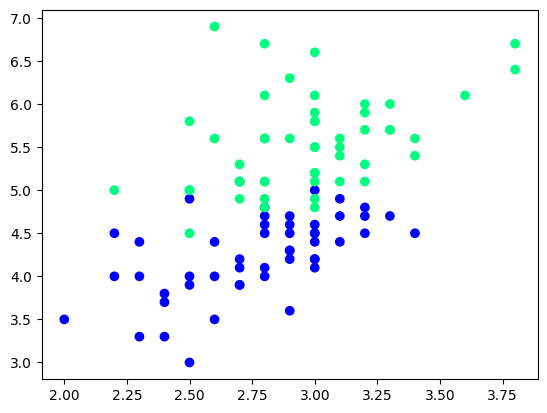

In [12]:
plt.scatter(df['sepal_width'],df['petal_length'],c=df['species'],cmap='winter')

In [13]:
df_train = df.iloc[:60,:].sample(10)
df_train

,sepal_width,petal_length,species
105,3.0,6.6,2
97,2.9,4.3,1
64,2.9,3.6,1
102,3.0,5.9,2
52,3.1,4.9,1
86,3.1,4.7,1
95,3.0,4.2,1
98,2.5,3.0,1
85,3.4,4.5,1
92,2.6,4.0,1


In [14]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [15]:

df_train

,sepal_width,petal_length,species
99,2.8,4.1,1
128,2.8,5.6,2
63,2.9,4.7,1
97,2.9,4.3,1
67,2.7,4.1,1
96,2.9,4.2,1
111,2.7,5.3,2
91,3.0,4.6,1
84,3.0,4.5,1
116,3.0,5.5,2


In [16]:
df_val

,sepal_width,petal_length,species
98,2.5,3.0,1
149,3.0,5.1,2
60,2.0,3.5,1
72,2.5,4.9,1
88,3.0,4.1,1


In [17]:
df_test

,sepal_width,petal_length,species
124,3.3,5.7,2
86,3.1,4.7,1
100,3.3,6.0,2
140,3.1,5.6,2
136,3.4,5.6,2


In [18]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [19]:
y_test

array([1, 2, 1, 1, 1])

# Case 1 - Bagging

In [20]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
67,2.7,4.1,1
91,3.0,4.6,1
128,2.8,5.6,2
84,3.0,4.5,1
99,2.8,4.1,1
91,3.0,4.6,1
99,2.8,4.1,1
116,3.0,5.5,2


In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [22]:
dt_bag1 = DecisionTreeClassifier()

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree

def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

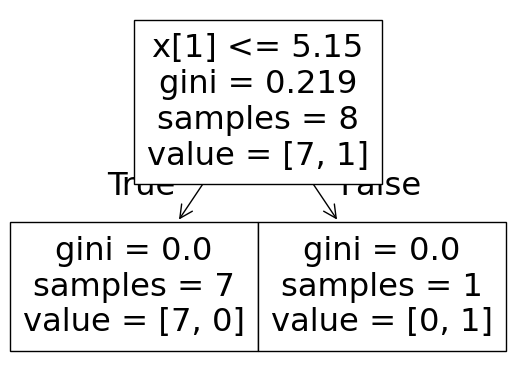

0.8


/home/nirdesho6o/miniconda3/envs/jupyter_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/nirdesho6o/miniconda3/envs/jupyter_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


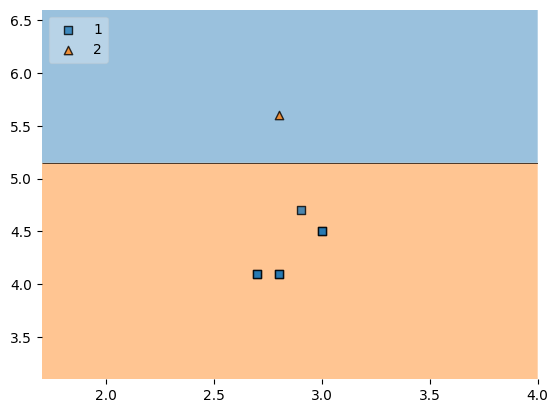

In [32]:
evaluate(dt_bag1,X,y)

In [33]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
67,2.7,4.1,1
91,3.0,4.6,1
96,2.9,4.2,1
99,2.8,4.1,1
63,2.9,4.7,1
96,2.9,4.2,1
116,3.0,5.5,2
97,2.9,4.3,1


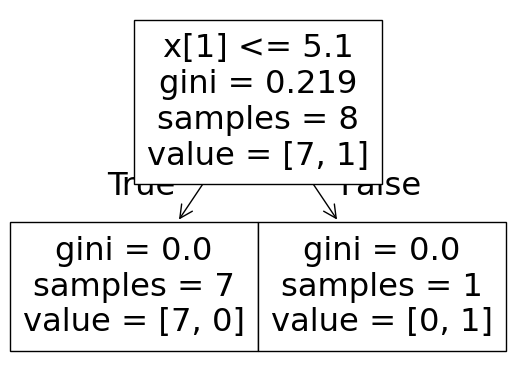

0.8


/home/nirdesho6o/miniconda3/envs/jupyter_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/nirdesho6o/miniconda3/envs/jupyter_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


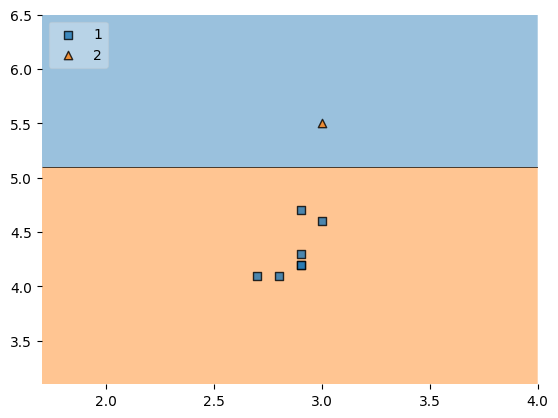

In [34]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [35]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
63,2.9,4.7,1
96,2.9,4.2,1
67,2.7,4.1,1
128,2.8,5.6,2
67,2.7,4.1,1
91,3.0,4.6,1
91,3.0,4.6,1
128,2.8,5.6,2


In [36]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
97,2.9,4.3,1
67,2.7,4.1,1
128,2.8,5.6,2
111,2.7,5.3,2
91,3.0,4.6,1
84,3.0,4.5,1
99,2.8,4.1,1
111,2.7,5.3,2


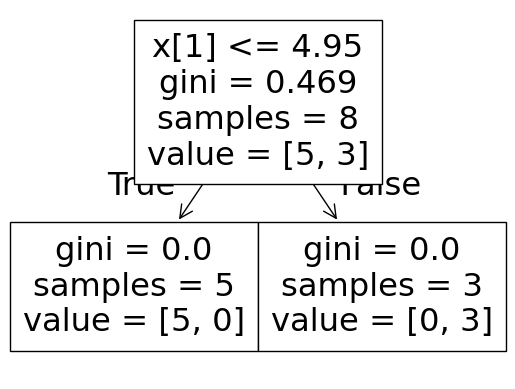

1.0


/home/nirdesho6o/miniconda3/envs/jupyter_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/nirdesho6o/miniconda3/envs/jupyter_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


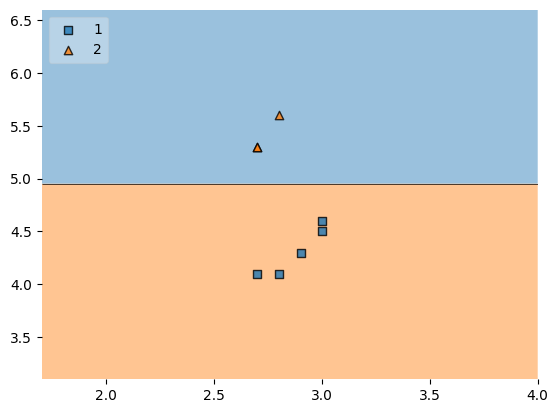

In [37]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)